# Explorative Datenanalyse

In diesem Notebook wird der Telecom-Churn-Datensatz zunächst strukturell untersucht. Ziel ist es, die Daten, ihre Merkmale und die Zielvariable `Churn` zu verstehen, bevor Datenbereinigung, Feature Engineering und Modellierung durchgeführt werden.


### Datensatz

Der Datensatz stammt aus dem UCI Machine Learning Repository und enthält Daten von 3.150 Kunden eines iranischen Telekommunikationsunternehmens. Die Eingangsmerkmale basieren auf aggregierten Kundendaten der ersten neun Monate. Die Zielvariable `Churn` beschreibt den Kundenstatus am Ende eines Zeitraums von zwölf Monaten.

Quelle: UCI Machine Learning Repository – Iranian Churn Dataset.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Datensatz laden

In [96]:
df = pd.read_csv("../data/raw/iranian_churn.csv")
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## Struktur des Datensatzes

In [97]:
df.shape


(3150, 14)

In [98]:
df.columns.tolist()

['Call  Failure',
 'Complains',
 'Subscription  Length',
 'Charge  Amount',
 'Seconds of Use',
 'Frequency of use',
 'Frequency of SMS',
 'Distinct Called Numbers',
 'Age Group',
 'Tariff Plan',
 'Status',
 'Age',
 'Customer Value',
 'Churn']

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

## Datenqualität

In [100]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(300)

## Zielvariable

In [102]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)

Churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

In [103]:
sorted(df["Charge  Amount"].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10)]

### Erste Beobachtungen

- Der Datensatz enthält 3.150 Beobachtungen und 14 Spalten.
- Alle Spalten wurden als numerische Datentypen eingelesen. Einige Merkmale sind jedoch kategorial bzw. binär codiert und müssen deshalb fachlich gesondert betrachtet werden.
- Es wurden keine fehlenden Werte gefunden.
- Im Datensatz treten 300 vollständig duplizierte Zeilen auf. Da keine eindeutige Kunden-ID vorhanden ist, wird zunächst geprüft, ob es sich tatsächlich um fehlerhafte Duplikate oder um Kunden mit identischen Merkmalsausprägungen handeln könnte.
- Die Zielvariable `Churn` ist ungleich verteilt: Rund 84,3 % der Beobachtungen gehören zur Klasse 0 und rund 15,7 % zur Klasse 1. Bei der späteren Modellbewertung sollte deshalb nicht ausschließlich die Accuracy betrachtet werden.

## Merkmalsausprägungen

In [104]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} eindeutige Werte")

Call  Failure: 37 eindeutige Werte
Complains: 2 eindeutige Werte
Subscription  Length: 45 eindeutige Werte
Charge  Amount: 11 eindeutige Werte
Seconds of Use: 1756 eindeutige Werte
Frequency of use: 242 eindeutige Werte
Frequency of SMS: 405 eindeutige Werte
Distinct Called Numbers: 92 eindeutige Werte
Age Group: 5 eindeutige Werte
Tariff Plan: 2 eindeutige Werte
Status: 2 eindeutige Werte
Age: 5 eindeutige Werte
Customer Value: 2654 eindeutige Werte
Churn: 2 eindeutige Werte


In [105]:
categorical_candidates = [
    "Complains",
    "Age Group",
    "Tariff Plan",
    "Status",
    "Churn"
]

for column in categorical_candidates:
    print(f"\n{column}:")
    print(df[column].value_counts().sort_index())


Complains:
Complains
0    2909
1     241
Name: count, dtype: int64

Age Group:
Age Group
1     123
2    1037
3    1425
4     395
5     170
Name: count, dtype: int64

Tariff Plan:
Tariff Plan
1    2905
2     245
Name: count, dtype: int64

Status:
Status
1    2368
2     782
Name: count, dtype: int64

Churn:
Churn
0    2655
1     495
Name: count, dtype: int64


## Untersuchung der Duplikate

In [106]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.shape

(465, 14)

In [107]:
duplicate_rows.head(10)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
5,11,0,38,1,3775,82,32,28,3,1,1,30,282.280,0
6,4,0,38,0,2360,39,285,18,3,1,1,30,1235.960,0
7,13,0,37,2,9115,121,144,43,3,1,1,30,945.440,0
8,7,0,38,0,13773,169,0,44,3,1,1,30,557.680,0
9,7,0,38,1,4515,83,2,25,3,1,1,30,191.920,0


In [108]:
df.value_counts().head(10)

Call  Failure  Complains  Subscription  Length  Charge  Amount  Seconds of Use  Frequency of use  Frequency of SMS  Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  Customer Value  Churn
0              0          35                    0               0               0                 0                 0                        2          1            2       25   0.000           1        6
                          37                    0               0               0                 0                 0                        2          1            2       25   0.000           0        6
                                                                                                                                                                                                  1        5
                          34                    0               0               0                 0                 0                        5          1            1       55   0.000  

### Zwischenfazit zur Datenqualität

- Der Datensatz enthält keine fehlenden Werte.
- Die Zielvariable ist unausgeglichen: 2.655 Beobachtungen gehören zur Klasse `0` und 495 zur Klasse `1`.
- Einige numerisch gespeicherte Variablen repräsentieren binäre oder kategoriale Merkmale.
- 300 Zeilen sind vollständige Duplikate. Insgesamt gehören 465 Zeilen zu Duplikatgruppen.
- Da keine eindeutige Kunden-ID vorhanden ist, werden diese Beobachtungen nicht vorschnell entfernt. Zunächst wird untersucht, ob identische Eingangsmerkmale unterschiedliche Zielwerte besitzen und welche Auswirkungen die Duplikate auf die spätere Modellierung haben könnten.

### Ausprägungen ausgewählter Merkmale

In [109]:
columns_to_inspect = [
    "Age",
    "Age Group",
    "Charge  Amount",
    "Complains",
    "Tariff Plan",
    "Status"
]

for column in columns_to_inspect:
    print(f"\n{column}:")
    print(df[column].value_counts().sort_index())


Age:
Age
15     123
25    1037
30    1425
45     395
55     170
Name: count, dtype: int64

Age Group:
Age Group
1     123
2    1037
3    1425
4     395
5     170
Name: count, dtype: int64

Charge  Amount:
Charge  Amount
0     1768
1      617
2      395
3      199
4       76
5       30
6       11
7       14
8       19
9       14
10       7
Name: count, dtype: int64

Complains:
Complains
0    2909
1     241
Name: count, dtype: int64

Tariff Plan:
Tariff Plan
1    2905
2     245
Name: count, dtype: int64

Status:
Status
1    2368
2     782
Name: count, dtype: int64


### Duplikate auf Basis der Eingangsmerkmale

In [110]:
feature_columns = df.columns.drop("Churn")

df.duplicated(subset=feature_columns).sum()

np.int64(314)

In [111]:
label_counts_per_profile = (
    df.groupby(list(feature_columns))["Churn"]
      .nunique()
)

(label_counts_per_profile > 1).sum()

np.int64(14)

### Zwischenfazit zu Duplikaten

Bei der Prüfung wurden 300 vollständig duplizierte Zeilen gefunden. Werden nur die Eingangsmerkmale betrachtet und `Churn` ausgeschlossen, erhöht sich die Zahl der Duplikate auf 314. Außerdem existieren 14 Featureprofile, die mit unterschiedlichen Churn-Werten auftreten.

Da keine eindeutige Kunden-ID vorhanden ist, können identische Merkmalsprofile verschiedene Kunden repräsentieren. Vollständig identische Beobachtungen könnten jedoch beim späteren Train/Test Split zu Informationsüberschneidungen führen. Die endgültige Behandlung der Duplikate erfolgt deshalb im Preprocessing.

### Zusammenhang zwischen `Age` und `Age Group`

In [112]:
pd.crosstab(df["Age Group"], df["Age"])

Age,15,25,30,45,55
Age Group,,,,,
1,123,0,0,0,0
2,0,1037,0,0,0
3,0,0,1425,0,0
4,0,0,0,395,0
5,0,0,0,0,170


### Redundanz zwischen `Age` und `Age Group`

Die Kreuztabelle zeigt eine eindeutige 1:1-Zuordnung zwischen `Age Group` und `Age`. Jede Altersgruppe entspricht genau einem Wert der Variable `Age`. Beide Merkmale enthalten damit im vorliegenden Datensatz dieselbe Information.

Um redundante Features zu vermeiden, soll im späteren Preprocessing nur eines der beiden Merkmale für die Modellierung verwendet werden.

### Featureprofile mit unterschiedlichen Churn-Werten

In [113]:
conflicting_profiles = (
    label_counts_per_profile[label_counts_per_profile > 1]
    .rename("number_of_churn_labels")
    .reset_index()
)

conflicting_profiles

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,number_of_churn_labels
0,0,0,26,0,825,10,21,3,4,1,2,45,73.375,2
1,0,0,29,0,0,0,0,0,2,1,2,25,0.000,2
2,0,0,30,0,0,0,0,0,2,1,2,25,0.000,2
3,0,0,31,0,0,0,0,0,2,1,2,25,0.000,2
4,0,0,32,0,0,0,0,0,2,1,2,25,0.000,2
5,0,0,33,0,0,0,0,0,2,1,2,25,0.000,2
6,0,0,34,0,0,0,0,0,2,1,2,25,0.000,2
7,0,0,35,0,0,0,0,0,2,1,2,25,0.000,2
8,0,0,36,0,0,0,0,0,2,1,2,25,0.000,2
9,0,0,37,0,0,0,0,0,2,1,2,25,0.000,2


In [114]:
conflicting_rows = df.merge(
    conflicting_profiles[feature_columns.tolist()],
    on=feature_columns.tolist(),
    how="inner"
)

conflicting_rows = conflicting_rows.sort_values(
    feature_columns.tolist()
)

conflicting_rows.head(30)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
2,0,0,26,0,825,10,21,3,4,1,2,45,73.375,1
20,0,0,26,0,825,10,21,3,4,1,2,45,73.375,0
23,0,0,26,0,825,10,21,3,4,1,2,45,73.375,0
32,0,0,29,0,0,0,0,0,2,1,2,25,0.000,0
34,0,0,29,0,0,0,0,0,2,1,2,25,0.000,1
51,0,0,29,0,0,0,0,0,2,1,2,25,0.000,1
30,0,0,30,0,0,0,0,0,2,1,2,25,0.000,1
33,0,0,30,0,0,0,0,0,2,1,2,25,0.000,0
50,0,0,30,0,0,0,0,0,2,1,2,25,0.000,1
7,0,0,31,0,0,0,0,0,2,1,2,25,0.000,1


Von den Featureprofilen treten 14 mit mehr als einem Churn-Label auf. Das bedeutet, dass Kunden mit identischen beobachteten Eingangsmerkmalen teilweise unterschiedliche Churn-Ergebnisse besitzen. Dies kann darauf hinweisen, dass nicht alle Faktoren, die eine Kündigung beeinflussen, im Datensatz enthalten sind.

Da keine eindeutige Kunden-ID vorhanden ist, werden diese Beobachtungen in der explorativen Analyse nicht entfernt. Die Behandlung vollständiger Duplikate wird im Preprocessing festgelegt.

## Verteilung der Zielvariable

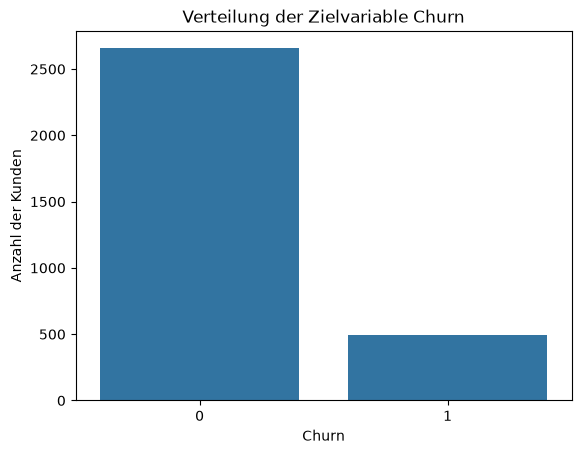

In [135]:
sns.countplot(data=df, x="Churn")

plt.title("Verteilung der Zielvariable Churn")
plt.xlabel("Churn")
plt.ylabel("Anzahl der Kunden")

plt.savefig(
    "../reports/figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Die Zielvariable ist deutlich unausgeglichen. Von 3.150 Beobachtungen gehören 2.655 zur Klasse `0` und 495 zur Klasse `1`. Damit beträgt der Anteil der Churn-Klasse rund 15,7 %.

Aufgrund dieses Klassenungleichgewichts ist die Accuracy allein später keine ausreichende Bewertungsmetrik. Zusätzlich werden unter anderem Precision, Recall, F1-Score und ROC-AUC betrachtet.

## Churn-Rate nach Beschwerden 

In [116]:
churn_by_complaints = (
    df.groupby("Complains")["Churn"]
      .mean()
      .mul(100)
)

churn_by_complaints

Complains
0    10.140942
1    82.987552
Name: Churn, dtype: float64

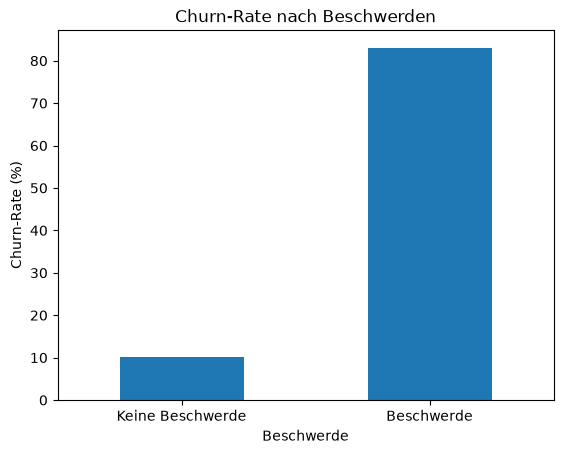

In [136]:
churn_by_complaints.plot(kind="bar")

plt.title("Churn-Rate nach Beschwerden")
plt.xlabel("Beschwerde")
plt.ylabel("Churn-Rate (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Keine Beschwerde", "Beschwerde"],
    rotation=0
)

plt.savefig(
    "../reports/figures/churn_by_complaints.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Churn-Rate nach Status

In [118]:
churn_by_status = (
    df.groupby("Status")["Churn"]
      .mean()
      .mul(100)
)

churn_by_status

Status
1     5.278716
2    47.314578
Name: Churn, dtype: float64

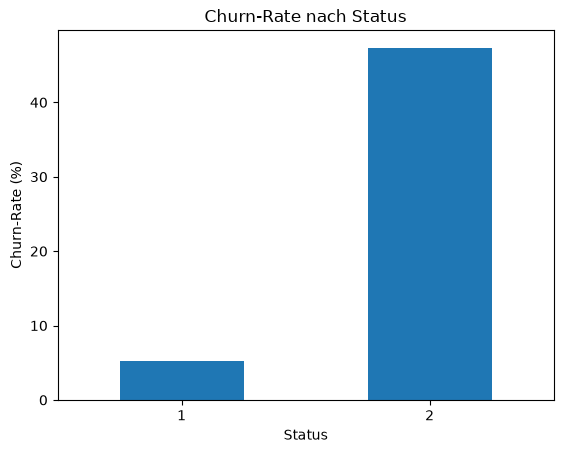

In [119]:
churn_by_status.plot(kind="bar")

plt.title("Churn-Rate nach Status")
plt.xlabel("Status")
plt.ylabel("Churn-Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [120]:
print("Churn-Rate nach Beschwerden:")
print(churn_by_complaints.round(2))

print("\nChurn-Rate nach Status:")
print(churn_by_status.round(2))

Churn-Rate nach Beschwerden:
Complains
0    10.14
1    82.99
Name: Churn, dtype: float64

Churn-Rate nach Status:
Status
1     5.28
2    47.31
Name: Churn, dtype: float64


### Interpretation

Kunden mit einer registrierten Beschwerde weisen eine deutlich höhere Churn-Rate auf als Kunden ohne Beschwerde. Beschwerden sind damit in diesem Datensatz stark mit Kundenabwanderung verbunden.

Auch beim Kundenstatus zeigt sich ein deutlicher Unterschied: Nicht-aktive Kunden weisen eine wesentlich höhere Churn-Rate auf als aktive Kunden.

Die beobachteten Zusammenhänge zeigen Assoziationen und erlauben keine direkte Aussage über Kausalität.

### Churn-Rate nach Tarifplan

In [121]:
churn_by_tariff = (
    df.groupby("Tariff Plan")["Churn"]
      .mean()
      .mul(100)
)

churn_by_tariff.round(2)

Tariff Plan
1    16.83
2     2.45
Name: Churn, dtype: float64

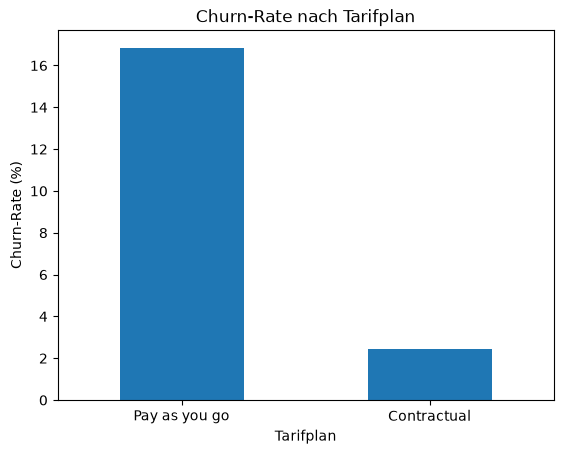

In [122]:
churn_by_tariff.plot(kind="bar")

plt.title("Churn-Rate nach Tarifplan")
plt.xlabel("Tarifplan")
plt.ylabel("Churn-Rate (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Pay as you go", "Contractual"],
    rotation=0
)
plt.show()

### Churn-Rate nach Alter

In [123]:
churn_by_age = (
    df.groupby("Age")["Churn"]
      .mean()
      .mul(100)
)

churn_by_age.round(2)

Age
15     0.00
25    17.74
30    16.14
45    20.00
55     1.18
Name: Churn, dtype: float64

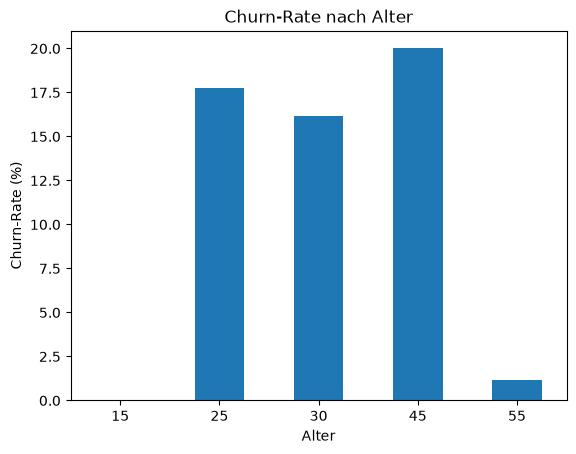

In [124]:
churn_by_age.plot(kind="bar")

plt.title("Churn-Rate nach Alter")
plt.xlabel("Alter")
plt.ylabel("Churn-Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Beim Tarifplan zeigt sich ein deutlicher Unterschied in der Churn-Rate. Kunden im Pay-as-you-go-Tarif weisen eine wesentlich höhere Churn-Rate auf als Kunden mit vertraglichem Tarif. Der Tarifplan könnte daher ein relevantes Merkmal für die spätere Churn-Vorhersage sein.

Auch zwischen den Altersgruppen bestehen Unterschiede. Der Zusammenhang ist jedoch nicht linear: Insbesondere die mittleren Altersgruppen weisen höhere Churn-Raten auf, während die jüngste und älteste Gruppe deutlich niedrigere Werte zeigen. Da `Age` und `Age Group` dieselbe Information abbilden, soll später nur eines der beiden Merkmale für die Modellierung verwendet werden.

`Charge Amount` besitzt die elf Ausprägungen 0 bis 10. Die Variable stellt damit keinen direkt interpretierbaren Geldbetrag dar, sondern eine codierte bzw. ordinale Größe. Ihre Beziehung zu Churn wird im weiteren Verlauf untersucht.

Die beobachteten Unterschiede stellen Zusammenhänge im Datensatz dar und erlauben keine kausalen Schlussfolgerungen.

### Churn-Rate nach Charge Amount

In [125]:
churn_by_charge = (
    df.groupby("Charge  Amount")["Churn"]
      .mean()
      .mul(100)
)

churn_by_charge.round(2)

Charge  Amount
0     23.81
1      6.97
2      5.82
3      3.52
4      1.32
5      0.00
6      0.00
7      0.00
8      0.00
9      0.00
10     0.00
Name: Churn, dtype: float64

In [126]:
charge_analysis = (
    df.groupby("Charge  Amount")
      .agg(
          customers=("Churn", "size"),
          churn_cases=("Churn", "sum"),
          churn_rate=("Churn", "mean")
      )
)

charge_analysis["churn_rate"] = (
    charge_analysis["churn_rate"] * 100
).round(2)

charge_analysis

,customers,churn_cases,churn_rate
Charge Amount,,,
0,1768,421,23.81
1,617,43,6.97
2,395,23,5.82
3,199,7,3.52
4,76,1,1.32
5,30,0,0.00
6,11,0,0.00
7,14,0,0.00
8,19,0,0.00


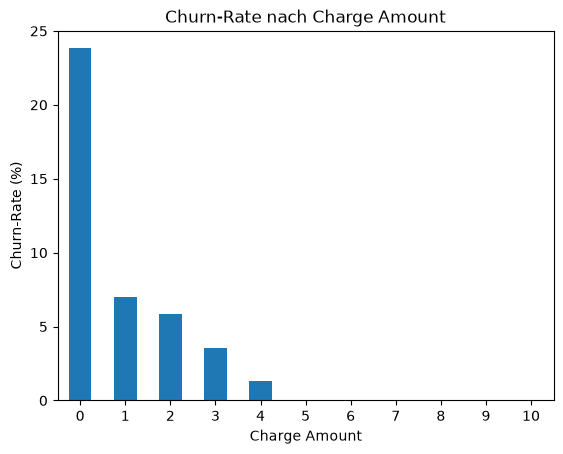

In [127]:
churn_by_charge.plot(kind="bar")

plt.title("Churn-Rate nach Charge Amount")
plt.xlabel("Charge Amount")
plt.ylabel("Churn-Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [128]:
charge_analysis = (
    df.groupby("Charge  Amount")
      .agg(
          customers=("Churn", "size"),
          churn_cases=("Churn", "sum"),
          churn_rate=("Churn", "mean")
      )
)

charge_analysis["churn_rate"] = (
    charge_analysis["churn_rate"] * 100
).round(2)

charge_analysis

,customers,churn_cases,churn_rate
Charge Amount,,,
0,1768,421,23.81
1,617,43,6.97
2,395,23,5.82
3,199,7,3.52
4,76,1,1.32
5,30,0,0.00
6,11,0,0.00
7,14,0,0.00
8,19,0,0.00


### Interpretation

Die Churn-Rate unterscheidet sich deutlich zwischen den `Charge Amount`-Stufen. In der Stufe 0 liegt die Churn-Rate bei 23,81 %, während sie bei den Stufen 1 bis 4 kontinuierlich abnimmt.

Von insgesamt 495 Churn-Fällen entfallen 421 auf Kunden mit `Charge Amount = 0`. Niedrige Ausprägungen dieses Merkmals sind damit im Datensatz stark mit Churn verbunden.

Für die Stufen 5 bis 10 wurden keine Churn-Fälle beobachtet. Diese Gruppen enthalten jedoch nur wenige Kunden, weshalb die Churn-Raten dort vorsichtig interpretiert werden müssen.

Aus dem beobachteten Zusammenhang kann keine Kausalität abgeleitet werden. `Charge Amount` könnte außerdem mit anderen Merkmalen wie Nutzungsintensität oder Kundenwert zusammenhängen.

Bei `Charge Amount` sinkt die beobachtete Churn-Rate mit steigender Stufe deutlich. Für die Interpretation müssen jedoch zusätzlich die Gruppengrößen betrachtet werden, da insbesondere seltene Ausprägungen zu instabilen Churn-Raten führen können.

## Nutzungsverhalten und Churn

In [129]:
usage_features = [
    "Seconds of Use",
    "Frequency of use",
    "Customer Value"
]

df.groupby("Churn")[usage_features].mean().round(2)

,Seconds of Use,Frequency of use,Customer Value
Churn,,,
0,5014.22,76.98,535.51
1,1566.63,29.13,124.81


In [130]:
df.groupby("Churn")[usage_features].median().round(2)

,Seconds of Use,Frequency of use,Customer Value
Churn,,,
0,3530.0,63.0,268.07
1,1182.0,25.0,96.84


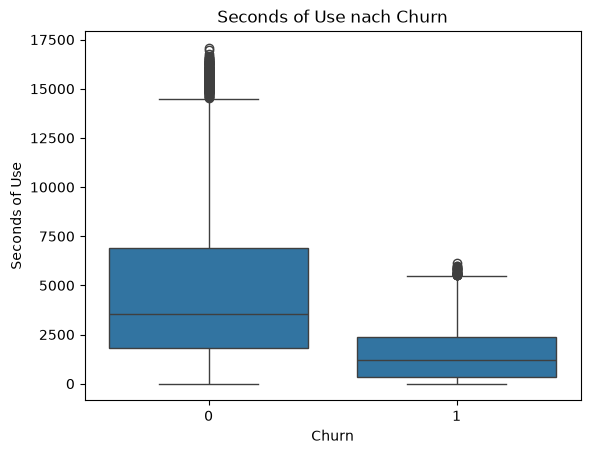

In [131]:
sns.boxplot(data=df, x="Churn", y="Seconds of Use")

plt.title("Seconds of Use nach Churn")
plt.xlabel("Churn")
plt.ylabel("Seconds of Use")
plt.show()

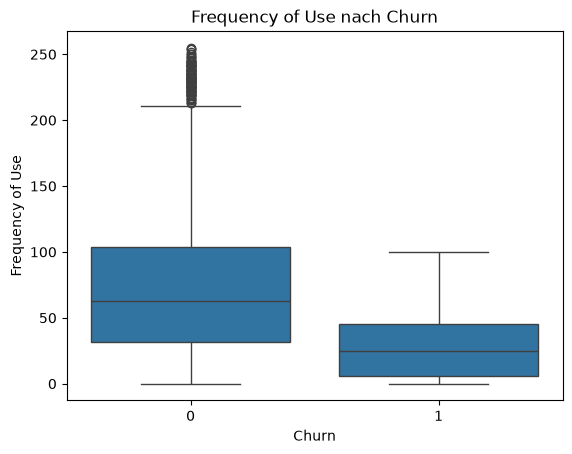

In [132]:
sns.boxplot(data=df, x="Churn", y="Frequency of use")

plt.title("Frequency of Use nach Churn")
plt.xlabel("Churn")
plt.ylabel("Frequency of Use")
plt.show()

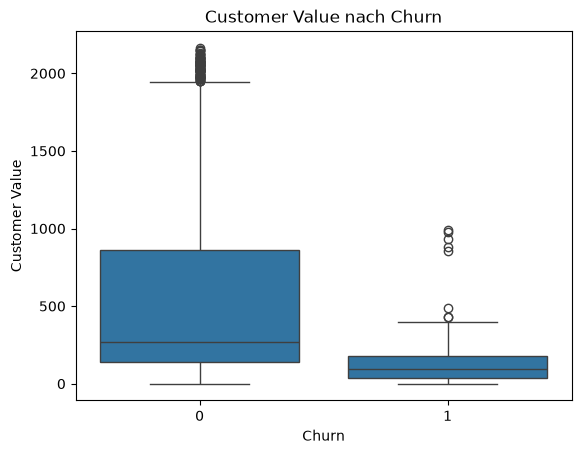

In [133]:
sns.boxplot(data=df, x="Churn", y="Customer Value")

plt.title("Customer Value nach Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Value")
plt.show()

### Interpretation des Nutzungsverhaltens

Zwischen dem Nutzungsverhalten und Churn zeigen sich deutliche Unterschiede. Kunden der Churn-Klasse weisen sowohl bei `Seconds of Use` als auch bei `Frequency of use` wesentlich niedrigere Mittelwerte und Mediane auf als Kunden, die nicht churnen.

Auch der `Customer Value` ist bei Churn-Kunden deutlich niedriger. Die Unterschiede zwischen Mittelwert und Median sowie die Boxplots zeigen gleichzeitig rechtsschiefe Verteilungen und mehrere hohe Ausreißer.

Die Ergebnisse deuten darauf hin, dass eine geringere Nutzung und ein niedrigerer Kundenwert mit einer höheren Churn-Wahrscheinlichkeit verbunden sind. Die Verteilungen überlappen sich jedoch, sodass keines dieser Merkmale Churn allein vollständig erklären kann.

## Korrelation zwischen ausgewählten Merkmalen

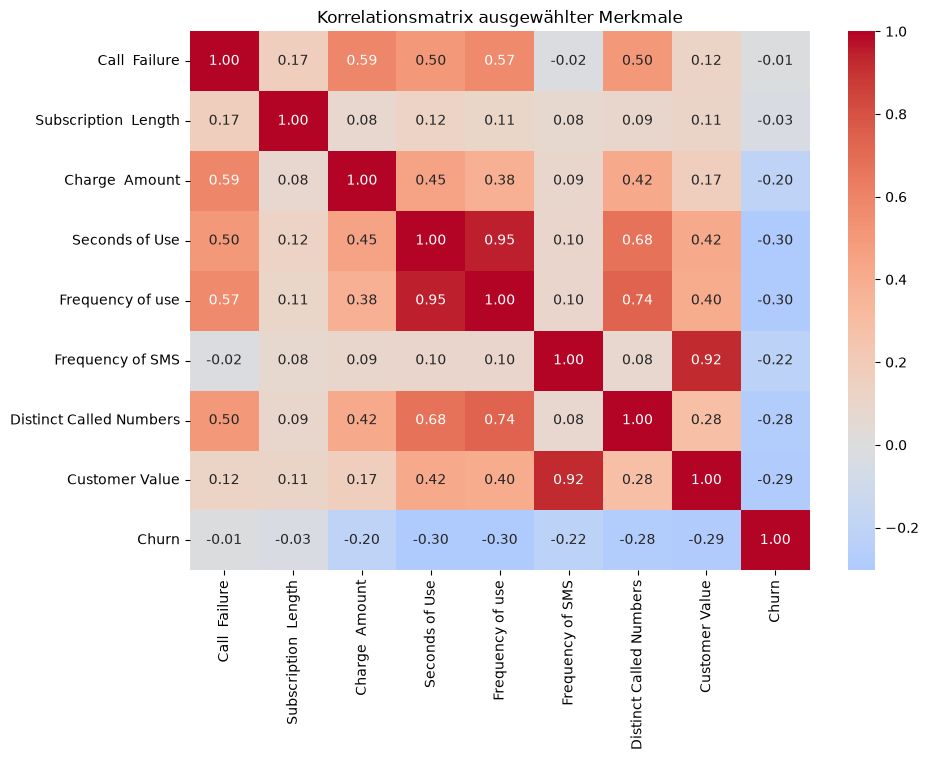

In [134]:
correlation_features = [
    "Call  Failure",
    "Subscription  Length",
    "Charge  Amount",
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Customer Value",
    "Churn"
]

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Korrelationsmatrix ausgewählter Merkmale")
plt.show()

### Interpretation der Korrelationsmatrix

Zwischen mehreren Nutzungsmerkmalen bestehen starke positive lineare Zusammenhänge. Besonders auffällig ist die Korrelation zwischen `Seconds of Use` und `Frequency of use` von 0,95. Auch `Frequency of SMS` und `Customer Value` sind mit 0,92 stark korreliert.

Diese hohen Korrelationen weisen auf teilweise redundante Informationen hin und werden insbesondere bei der späteren Verwendung der Logistic Regression berücksichtigt.

Mit der Zielvariable `Churn` weisen `Seconds of Use` und `Frequency of use` jeweils eine Korrelation von etwa -0,30 auf. Auch `Customer Value`, `Distinct Called Numbers`, `Frequency of SMS` und `Charge Amount` zeigen negative Zusammenhänge mit Churn. Dies unterstützt die vorherige Beobachtung, dass eine geringere Kundenaktivität mit einer höheren Churn-Rate verbunden ist.

`Call Failure` und `Subscription Length` weisen dagegen nur sehr geringe lineare Korrelationen mit Churn auf. Eine geringe Pearson-Korrelation bedeutet jedoch nicht automatisch, dass ein Merkmal für komplexere oder nichtlineare Modelle ohne Bedeutung ist.

Korrelationen beschreiben statistische Zusammenhänge und erlauben keine kausalen Schlussfolgerungen.

## Fazit der explorativen Datenanalyse

Die explorative Analyse zeigt mehrere für die spätere Modellierung relevante Eigenschaften des Datensatzes:

- Der Datensatz enthält 3.150 Beobachtungen und 14 Spalten und weist keine fehlenden Werte auf.
- Die Zielvariable `Churn` ist mit 495 Churn-Fällen gegenüber 2.655 Non-Churn-Fällen deutlich unausgeglichen.
- Es wurden 300 vollständig duplizierte Zeilen identifiziert. Da keine eindeutige Kunden-ID vorhanden ist, wird ihre Behandlung im Preprocessing gezielt festgelegt.
- `Age` und `Age Group` enthalten im vorliegenden Datensatz dieselbe Information und sollten daher nicht gleichzeitig für die Modellierung verwendet werden.
- Beschwerden und ein nicht-aktiver Kundenstatus sind mit deutlich höheren Churn-Raten verbunden.
- Kunden im Pay-as-you-go-Tarif weisen eine deutlich höhere Churn-Rate auf als Kunden mit vertraglichem Tarif.
- Churn-Kunden zeigen insgesamt eine geringere Nutzungsintensität und einen niedrigeren `Customer Value`.
- Niedrige `Charge Amount`-Stufen sind stärker mit Churn verbunden. Höhere Stufen enthalten jedoch teilweise nur wenige Beobachtungen und müssen entsprechend vorsichtig interpretiert werden.
- Zwischen mehreren Nutzungsmerkmalen bestehen starke Korrelationen, insbesondere zwischen `Seconds of Use` und `Frequency of use` sowie zwischen `Frequency of SMS` und `Customer Value`.

Diese Erkenntnisse bilden die Grundlage für die Datenbereinigung, Feature-Auswahl und Modellierung im nächsten Schritt.